# EXPLORATORY DATA ANALYSIS (EDA)
## Plateforme Prédictive CEVA Logistics - Flux Airbus

**Auteur:** Dorian | **Master:** AI/Data Product Management | **Date:** Mars 2025

---

**Dataset:** shipments_clean_AIR.csv (32,156 lignes AIR)  
**Période:** Janvier 2024 - Février 2026 (25 mois)  
**Objectif:** Comprendre données, identifier patterns, préparer ML

In [26]:
# ============================================================================
# SETUP & IMPORTS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import os

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Couleurs CEVA Logistics
CEVA_RED = '#E31937'
CEVA_BLUE = '#004B87'
CEVA_GRAY = '#95A5A6'
CEVA_PALETTE = [CEVA_BLUE, CEVA_RED, CEVA_GRAY, '#2ECC71', '#F39C12']

# Style graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Créer dossiers outputs
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

print("Setup OK")
print(f"Couleurs CEVA: Bleu {CEVA_BLUE} | Rouge {CEVA_RED}")

Setup OK
Couleurs CEVA: Bleu #004B87 | Rouge #E31937


In [27]:
# ============================================================================
# CHARGEMENT DATASET
# ============================================================================

# Chargement
df = pd.read_csv('../data/processed/shipments_clean_AIR.csv')

# Informations basiques
n_rows, n_cols = df.shape
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

print(f"Dataset chargé")
print(f"  Lignes: {n_rows:,}")
print(f"  Colonnes: {n_cols}")
print(f"  Mémoire: {memory_mb:.2f} MB")

Dataset chargé
  Lignes: 32,360
  Colonnes: 31
  Mémoire: 41.44 MB


In [28]:
# Filtrer uniquement 2024-2025
df = df[df['Creation_Date'] < '2026-01-01']
print(f"Après filtrage 2026 : {len(df):,} lignes")

Après filtrage 2026 : 30,774 lignes


In [29]:
print(f"\nTypes de données:")
print(df.dtypes.value_counts())
print(f"\nDétail par type:")
for dtype in df.dtypes.unique():
    cols = df.select_dtypes(include=[dtype]).columns.tolist()
    print(f"  {dtype}: {len(cols)} colonnes")
    print(f"    {', '.join(cols)}")


Types de données:
object     23
float64     5
int64       3
Name: count, dtype: int64

Détail par type:
  object: 23 colonnes
    Shipment_ID, CargoWise_Reference, Import_File_Number, Export_File_Number, Customer_Reference, Business_Unit, Creation_Date, Requested_Pickup_Date, Requested_Delivery_Date, Actual_Pickup_Date, Actual_Delivery_Date, Original_ETA, Origin_Country, Origin_City, Destination_Country, Destination_City, Carrier_Name, Mode_of_Transport, Service_Type, Hazardous, Incoterm, Exception_Codes, Route
  float64: 5 colonnes
    Gross_Weight_KG, Gross_Volume_M3, Actual_Lead_Time_Days, Delay_Days, Is_Delayed
  int64: 3 colonnes
    Number_of_Pieces, Requested_Lead_Time_Days, Exception_Count


In [30]:
# ============================================================================
# CONVERSION DATES
# ============================================================================

# Liste colonnes dates
date_cols = ['Creation_Date', 'Requested_Pickup_Date', 'Requested_Delivery_Date',
             'Actual_Pickup_Date', 'Actual_Delivery_Date', 'Original_ETA']

# Conversion en datetime
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Features temporelles pour analyse
df['Year'] = df['Creation_Date'].dt.year
df['Month'] = df['Creation_Date'].dt.month

# Période couverte
date_min = df['Creation_Date'].min()
date_max = df['Creation_Date'].max()
nb_jours = (date_max - date_min).days

print(f"Dates converties en datetime")
print(f"  Période: {date_min.date()} -> {date_max.date()}")
print(f"  Durée: {nb_jours} jours ({nb_jours/30:.1f} mois)")
print(f"\nFeatures créées:")
print(f"  Year (2024, 2025, 2026)")
print(f"  Month (1-12, pour saisonnalité)")

Dates converties en datetime
  Période: 2024-01-01 -> 2025-12-31
  Durée: 730 jours (24.3 mois)

Features créées:
  Year (2024, 2025, 2026)
  Month (1-12, pour saisonnalité)


In [31]:
# ============================================================================
# FEATURE ENGINEERING COMPLÉMENTAIRE (pour ML)
# ============================================================================

print("\n🔧 Création des features engineered pour modélisation...")

# 1. Pickup_DayOfWeek (0=Lundi, 6=Dimanche)
df['Pickup_DayOfWeek'] = df['Requested_Pickup_Date'].dt.dayofweek

# 2. Delivery_DayOfWeek
df['Delivery_DayOfWeek'] = df['Requested_Delivery_Date'].dt.dayofweek

# 3. Pickup_IsWeekend (1 si Samedi ou Dimanche)
df['Pickup_IsWeekend'] = (df['Pickup_DayOfWeek'] >= 5).astype(int)

# 4. Delivery_IsWeekend
df['Delivery_IsWeekend'] = (df['Delivery_DayOfWeek'] >= 5).astype(int)

# 5. Weight_Category (seuils : 500, 2000, 5000 kg)
def categorize_weight(weight):
    if weight < 500:
        return 'Light'
    elif weight < 2000:
        return 'Medium'
    elif weight < 5000:
        return 'Heavy'
    else:
        return 'VeryHeavy'

df['Weight_Category'] = df['Gross_Weight_KG'].apply(categorize_weight)

# 6. Is_Tier3 (pays hors UE/US/CA - destinations "complexes")
tier3_countries = ['AE', 'SA', 'QA', 'MA', 'EG', 'ZA', 'IN', 'KR', 'JP', 'BR', 'PL']
df['Is_Tier3'] = df['Destination_Country'].isin(tier3_countries).astype(int)

# 7. Pieces_Per_Ton (densité handling - indicateur complexité manutention)
df['Pieces_Per_Ton'] = df['Number_of_Pieces'] / (df['Gross_Weight_KG'] / 1000)
# Gérer divisions par zéro (remplacer inf par 0)
df['Pieces_Per_Ton'] = df['Pieces_Per_Ton'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Résumé
print("✅ Features engineered créées !")
print(f"\nNouveaux attributs temporels :")
print(f"  - Pickup_DayOfWeek : {df['Pickup_DayOfWeek'].nunique()} jours (0=Lun, 6=Dim)")
print(f"  - Delivery_DayOfWeek : {df['Delivery_DayOfWeek'].nunique()} jours")
print(f"  - Pickup_IsWeekend : {df['Pickup_IsWeekend'].value_counts().to_dict()}")
print(f"  - Delivery_IsWeekend : {df['Delivery_IsWeekend'].value_counts().to_dict()}")

print(f"\nCatégorisation poids :")
print(df['Weight_Category'].value_counts().sort_index())

print(f"\nDestinations Tier 3 (hors UE/US/CA) :")
print(f"  - Oui : {df['Is_Tier3'].sum()} shipments ({df['Is_Tier3'].mean()*100:.1f}%)")
print(f"  - Non : {(1-df['Is_Tier3']).sum()} shipments")

print(f"\nPieces_Per_Ton (densité) :")
print(f"  - Min : {df['Pieces_Per_Ton'].min():.2f}")
print(f"  - Max : {df['Pieces_Per_Ton'].max():.2f}")
print(f"  - Moyenne : {df['Pieces_Per_Ton'].mean():.2f}")


🔧 Création des features engineered pour modélisation...
✅ Features engineered créées !

Nouveaux attributs temporels :
  - Pickup_DayOfWeek : 7 jours (0=Lun, 6=Dim)
  - Delivery_DayOfWeek : 7 jours
  - Pickup_IsWeekend : {0: 22122, 1: 8652}
  - Delivery_IsWeekend : {0: 21796, 1: 8978}

Catégorisation poids :
Weight_Category
Heavy         9247
Light         1819
Medium       15656
VeryHeavy     4052
Name: count, dtype: int64

Destinations Tier 3 (hors UE/US/CA) :
  - Oui : 1539 shipments (5.0%)
  - Non : 29235 shipments

Pieces_Per_Ton (densité) :
  - Min : 0.07
  - Max : 24.10
  - Moyenne : 4.65


In [32]:
# ============================================================================
# APERÇU DONNÉES & VÉRIFICATION
# ============================================================================

# Premières lignes
print("Premières lignes du dataset:")
display(df.head())

# Informations techniques
print("\nInformations techniques:")
df.info()

# Vérification valeurs manquantes
print("\nValeurs manquantes (NaN):")
missing = df.isnull().sum()
print(missing[missing > 0])

Premières lignes du dataset:


,Shipment_ID,CargoWise_Reference,Import_File_Number,Export_File_Number,Customer_Reference,Business_Unit,Creation_Date,Requested_Pickup_Date,Requested_Delivery_Date,Actual_Pickup_Date,Actual_Delivery_Date,Original_ETA,Origin_Country,Origin_City,Destination_Country,Destination_City,Carrier_Name,Mode_of_Transport,Service_Type,Gross_Weight_KG,Gross_Volume_M3,Number_of_Pieces,Hazardous,Incoterm,Requested_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Is_Delayed,Exception_Codes,Exception_Count,Route,Year,Month,Pickup_DayOfWeek,Delivery_DayOfWeek,Pickup_IsWeekend,Delivery_IsWeekend,Weight_Category,Is_Tier3,Pieces_Per_Ton
0,SHP456778,S5661907,NaN,CN-PEK-832052,ABS38221,ADS,2024-01-03,2024-01-04,2024-01-12,2024-01-03,2024-01-12,2024-01-11,CN,PEK,ES,MAD,British Airways Cargo,AIR,RTN,5119.36,1.6037,11,Y,FCA,7,8.0,0.0,0.0,NaN,0,CN→ES,2024,1,3,4,0,0,VeryHeavy,0,2.148706
1,SHP793384,S4823498,FR-TLS-148050,US-DFW-172933,FIN20458,ADS,2024-02-15,2024-02-16,2024-02-23,2024-02-16,2024-02-23,2024-02-24,US,DFW,FR,TLS,Singapore Airlines Cargo,AIR,RTN,3497.48,1.7112,22,N,EXW,6,6.0,0.0,0.0,NaN,0,US→FR,2024,2,4,4,0,0,Heavy,0,6.290243
2,SHP617488,S2525206,FR-TLS-634277,US-ORD-245051,AIR24371,ADS,2025-06-13,2025-06-15,2025-06-22,2025-06-16,2025-06-22,2025-06-21,US,ORD,FR,TLS,Singapore Airlines Cargo,AIR,RTN,9476.54,3.5046,22,Y,EXW,5,5.0,0.0,0.0,NaN,0,US→FR,2025,6,6,6,1,1,VeryHeavy,0,2.321522
3,SHP624902,S3997281,FR-MRS-376183,CN-CAN-854639,AIR91959,AC,2025-01-09,2025-01-12,2025-01-19,2025-01-13,2025-01-20,2025-01-20,CN,CAN,FR,MRS,British Airways Cargo,AIR,RTN,955.82,0.6125,6,N,EXW,5,6.0,1.0,1.0,D33,1,CN→FR,2025,1,6,6,1,1,Medium,0,6.277333
4,SHP903035,S3109911,FR-TLS-658582,US-JFK-897549,ABS96474,AC,2025-12-30,2026-01-02,2026-01-07,2026-01-01,2026-01-12,2026-01-06,US,JFK,FR,TLS,Panalpina Air,AIR,RTN,955.83,0.2961,4,N,EXW,4,8.0,5.0,1.0,D04,1,US→FR,2025,12,4,2,0,0,Medium,0,4.184845



Informations techniques:
<class 'pandas.core.frame.DataFrame'>
Index: 30774 entries, 0 to 32358
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Shipment_ID               30774 non-null  object        
 1   CargoWise_Reference       30774 non-null  object        
 2   Import_File_Number        25708 non-null  object        
 3   Export_File_Number        27031 non-null  object        
 4   Customer_Reference        30774 non-null  object        
 5   Business_Unit             30774 non-null  object        
 6   Creation_Date             30774 non-null  datetime64[ns]
 7   Requested_Pickup_Date     30774 non-null  datetime64[ns]
 8   Requested_Delivery_Date   30774 non-null  datetime64[ns]
 9   Actual_Pickup_Date        30456 non-null  datetime64[ns]
 10  Actual_Delivery_Date      29816 non-null  datetime64[ns]
 11  Original_ETA              28342 non-null  datetime64[ns]
 1

In [33]:
# ============================================================================
# VÉRIFICATION INCOHÉRENCES COMPLÈTES
# ============================================================================

# Lignes avec dates manquantes
missing_pickup = df['Actual_Pickup_Date'].isna()
missing_delivery = df['Actual_Delivery_Date'].isna()
missing_dates = missing_pickup | missing_delivery

print(f"Lignes avec dates manquantes :")
print(f"  Actual_Pickup_Date manquant : {missing_pickup.sum()}")
print(f"  Actual_Delivery_Date manquant : {missing_delivery.sum()}")
print(f"  Au moins une date manquante : {missing_dates.sum()}")

# Vérifier incohérences
incoherent_leadtime = df[missing_dates & (df['Actual_Lead_Time_Days'] != 0)]
incoherent_delay = df[missing_dates & (df['Delay_Days'] != 0)]
incoherent_delayed = df[missing_dates & (df['Is_Delayed'] == 1)]

print(f"\nIncohérences détectées :")
print(f"  Actual_Lead_Time_Days rempli : {len(incoherent_leadtime)}")
print(f"  Delay_Days rempli : {len(incoherent_delay)}")
print(f"  Is_Delayed = 1 : {len(incoherent_delayed)}")

# Afficher exemples
if len(incoherent_delayed) > 0:
    print("\nExemples lignes incohérentes :")
    display(df[missing_dates & (df['Is_Delayed'] == 1)][[
        'Shipment_ID', 'Actual_Pickup_Date', 'Actual_Delivery_Date',
        'Actual_Lead_Time_Days', 'Delay_Days', 'Is_Delayed'
    ]].head(10))

Lignes avec dates manquantes :
  Actual_Pickup_Date manquant : 318
  Actual_Delivery_Date manquant : 958
  Au moins une date manquante : 1114

Incohérences détectées :
  Actual_Lead_Time_Days rempli : 1114
  Delay_Days rempli : 1114
  Is_Delayed = 1 : 0


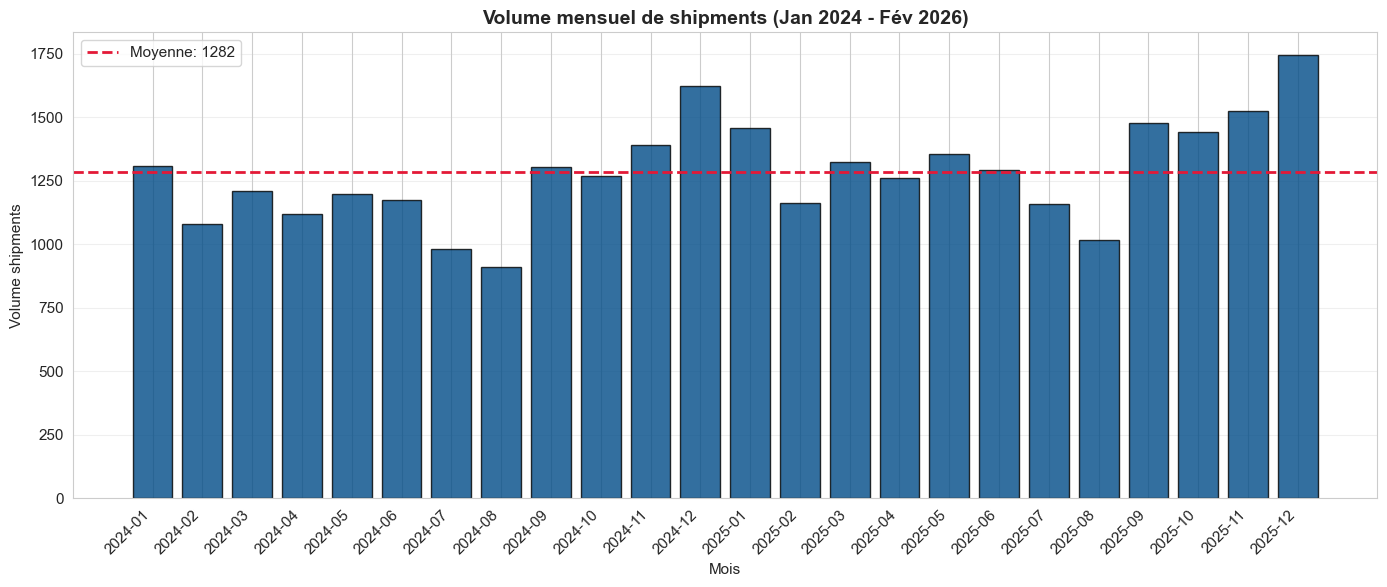

STATISTIQUES VOLUME MENSUEL:
  Volume moyen : 1282 shipments/mois
  Volume max : 1746 shipments (2025-12)
  Volume min : 911 shipments (2024-08)
  Écart max-min : 835 shipments


In [34]:
# ============================================================================
# ANALYSE TEMPORELLE : VOLUME MENSUEL
# ============================================================================

# Créer période mensuelle
df['YearMonth'] = df['Creation_Date'].dt.to_period('M')

# Compter shipments par mois
monthly_volume = df.groupby('YearMonth').size()

# Stats
volume_mean = monthly_volume.mean()
volume_max = monthly_volume.max()
volume_min = monthly_volume.min()
month_max = monthly_volume.idxmax()
month_min = monthly_volume.idxmin()

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(monthly_volume)), monthly_volume.values, color=CEVA_BLUE, edgecolor='black', alpha=0.8)
ax.axhline(volume_mean, color=CEVA_RED, linestyle='--', linewidth=2, label=f'Moyenne: {volume_mean:.0f}')
ax.set_xticks(range(len(monthly_volume)))
ax.set_xticklabels([str(m) for m in monthly_volume.index], rotation=45, ha='right')
ax.set_xlabel('Mois')
ax.set_ylabel('Volume shipments')
ax.set_title('Volume mensuel de shipments (Jan 2024 - Fév 2026)', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/01_monthly_volume.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats texte
print(f"STATISTIQUES VOLUME MENSUEL:")
print(f"  Volume moyen : {volume_mean:.0f} shipments/mois")
print(f"  Volume max : {volume_max} shipments ({month_max})")
print(f"  Volume min : {volume_min} shipments ({month_min})")
print(f"  Écart max-min : {volume_max - volume_min} shipments")

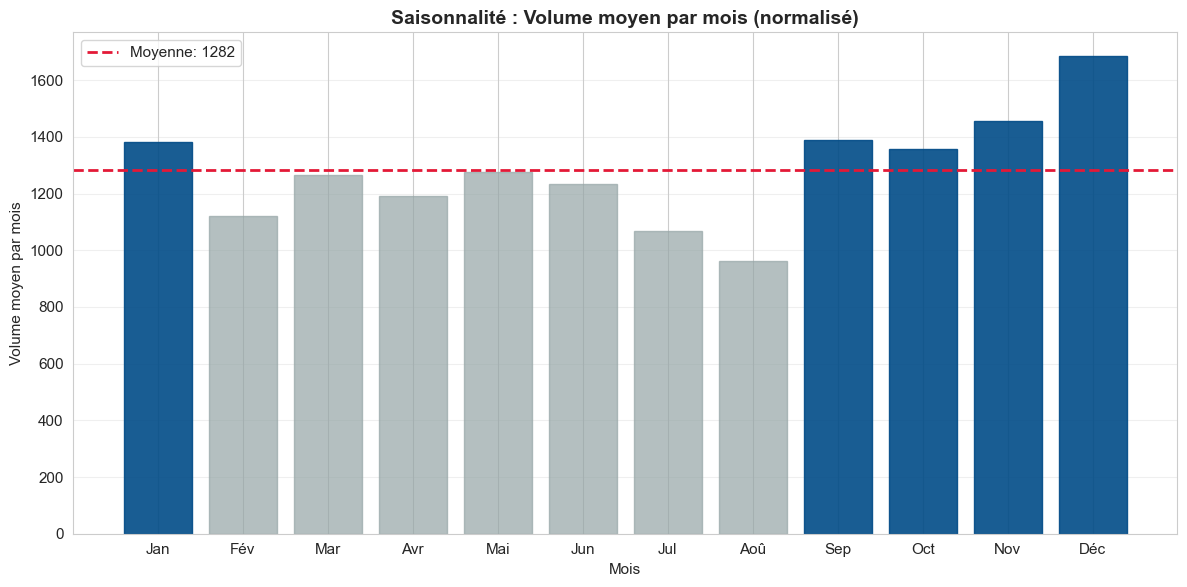

SAISONNALITÉ DÉTECTÉE:
  Moyenne : 1282 shipments/mois
  Mois MAX : Déc (1684 shipments, +31%)
  Mois MIN : Aoû (964 shipments, -25%)


In [35]:
# ============================================================================
# SAISONNALITÉ : PATTERN MENSUEL AGRÉGÉ (NORMALISÉ)
# ============================================================================

# Volume par mois + année
monthly_yearly = df.groupby(['Year', 'Month']).size().reset_index(name='Volume')

# Compter occurrences de chaque mois (certains mois ont 2 ou 3 années)
month_occurrences = monthly_yearly.groupby('Month').size()

# Volume moyen par mois (normalisé)
monthly_pattern = monthly_yearly.groupby('Month')['Volume'].mean()
average_volume = monthly_pattern.mean()

# Noms des mois
month_names = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 
               'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

# Graphique
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(month_names, monthly_pattern.values, color=CEVA_BLUE, edgecolor='black', alpha=0.8)

# Ligne moyenne
ax.axhline(average_volume, color=CEVA_RED, linestyle='--', linewidth=2, 
           label=f'Moyenne: {average_volume:.0f}')

# Colorer différemment au-dessus/en-dessous moyenne
for i, bar in enumerate(bars):
    if monthly_pattern.values[i] > average_volume:
        bar.set_color(CEVA_BLUE)
        bar.set_alpha(0.9)
    else:
        bar.set_color(CEVA_GRAY)
        bar.set_alpha(0.7)

ax.set_xlabel('Mois')
ax.set_ylabel('Volume moyen par mois')
ax.set_title('Saisonnalité : Volume moyen par mois (normalisé)', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/02_seasonality_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats
max_idx = monthly_pattern.values.argmax()
min_idx = monthly_pattern.values.argmin()
print(f"SAISONNALITÉ DÉTECTÉE:")
print(f"  Moyenne : {average_volume:.0f} shipments/mois")
print(f"  Mois MAX : {month_names[max_idx]} ({monthly_pattern.values[max_idx]:.0f} shipments, +{(monthly_pattern.values[max_idx]/average_volume-1)*100:.0f}%)")
print(f"  Mois MIN : {month_names[min_idx]} ({monthly_pattern.values[min_idx]:.0f} shipments, {(monthly_pattern.values[min_idx]/average_volume-1)*100:.0f}%)")

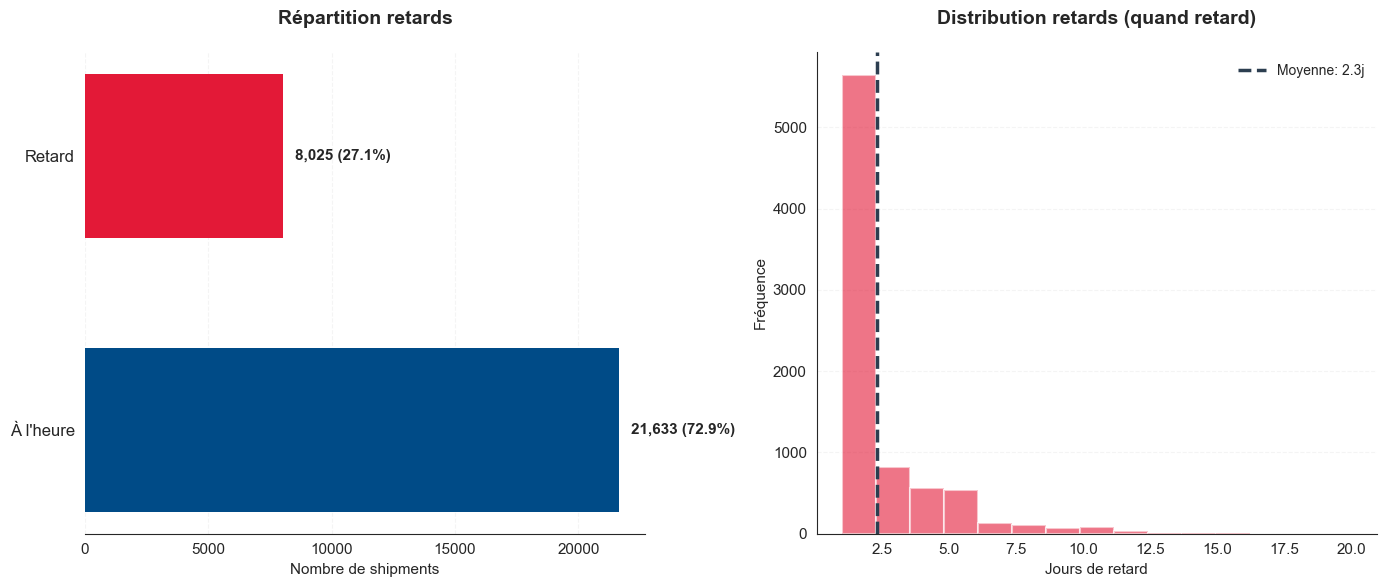

ANALYSE RETARDS:
  Shipments terminés : 29,658
  À l'heure : 21,633 (72.9%)
  Retards : 8,025 (27.1%)

QUAND RETARD:
  Jours moyen : 2.3
  Médiane : 1j
  Max : 20j


In [36]:
# ============================================================================
# ANALYSE RETARDS : VUE GLOBALE (VERSION MODERNE)
# ============================================================================

# Stats retards (on exclut les NaN = shipments en cours)
completed = df['Is_Delayed'].notna()
total_completed = completed.sum()
delayed = df[completed]['Is_Delayed'].sum()
ontime = total_completed - delayed
delay_rate = (delayed / total_completed) * 100

# Style moderne
sns.set_style('white')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1 : Barres horizontales modernes
categories = ['À l\'heure', 'Retard']
values = [ontime, delayed]
colors = [CEVA_BLUE, CEVA_RED]

y_pos = [0, 1]
bars = ax1.barh(y_pos, values, color=colors, height=0.6, edgecolor='none')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories, fontsize=12)
ax1.set_xlabel('Nombre de shipments', fontsize=11)
ax1.set_title('Répartition retards', fontweight='bold', fontsize=14, pad=20)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.grid(axis='x', alpha=0.2, linestyle='--')

# Annoter valeurs
for i, (bar, val) in enumerate(zip(bars, values)):
    pct = (val / total_completed) * 100
    ax1.text(val + 500, bar.get_y() + bar.get_height()/2, 
             f'{int(val):,} ({pct:.1f}%)', 
             va='center', fontweight='bold', fontsize=11)

# Panel 2 : Histogramme moderne (style KDE overlay)
delayed_days = df[df['Is_Delayed'] == 1]['Delay_Days']
ax2.hist(delayed_days, bins=15, color=CEVA_RED, alpha=0.6, edgecolor='white', linewidth=1.5)
ax2.axvline(delayed_days.mean(), color='#2c3e50', linestyle='--', linewidth=2.5, 
            label=f'Moyenne: {delayed_days.mean():.1f}j')
ax2.set_xlabel('Jours de retard', fontsize=11)
ax2.set_ylabel('Fréquence', fontsize=11)
ax2.set_title('Distribution retards (quand retard)', fontweight='bold', fontsize=14, pad=20)
ax2.legend(frameon=False, fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/figures/04_delays_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# Remettre style par défaut
sns.set_style('whitegrid')

# Stats texte
print(f"ANALYSE RETARDS:")
print(f"  Shipments terminés : {total_completed:,}")
print(f"  À l'heure : {int(ontime):,} ({100-delay_rate:.1f}%)")
print(f"  Retards : {int(delayed):,} ({delay_rate:.1f}%)")
print(f"\nQUAND RETARD:")
print(f"  Jours moyen : {delayed_days.mean():.1f}")
print(f"  Médiane : {delayed_days.median():.0f}j")
print(f"  Max : {delayed_days.max():.0f}j")

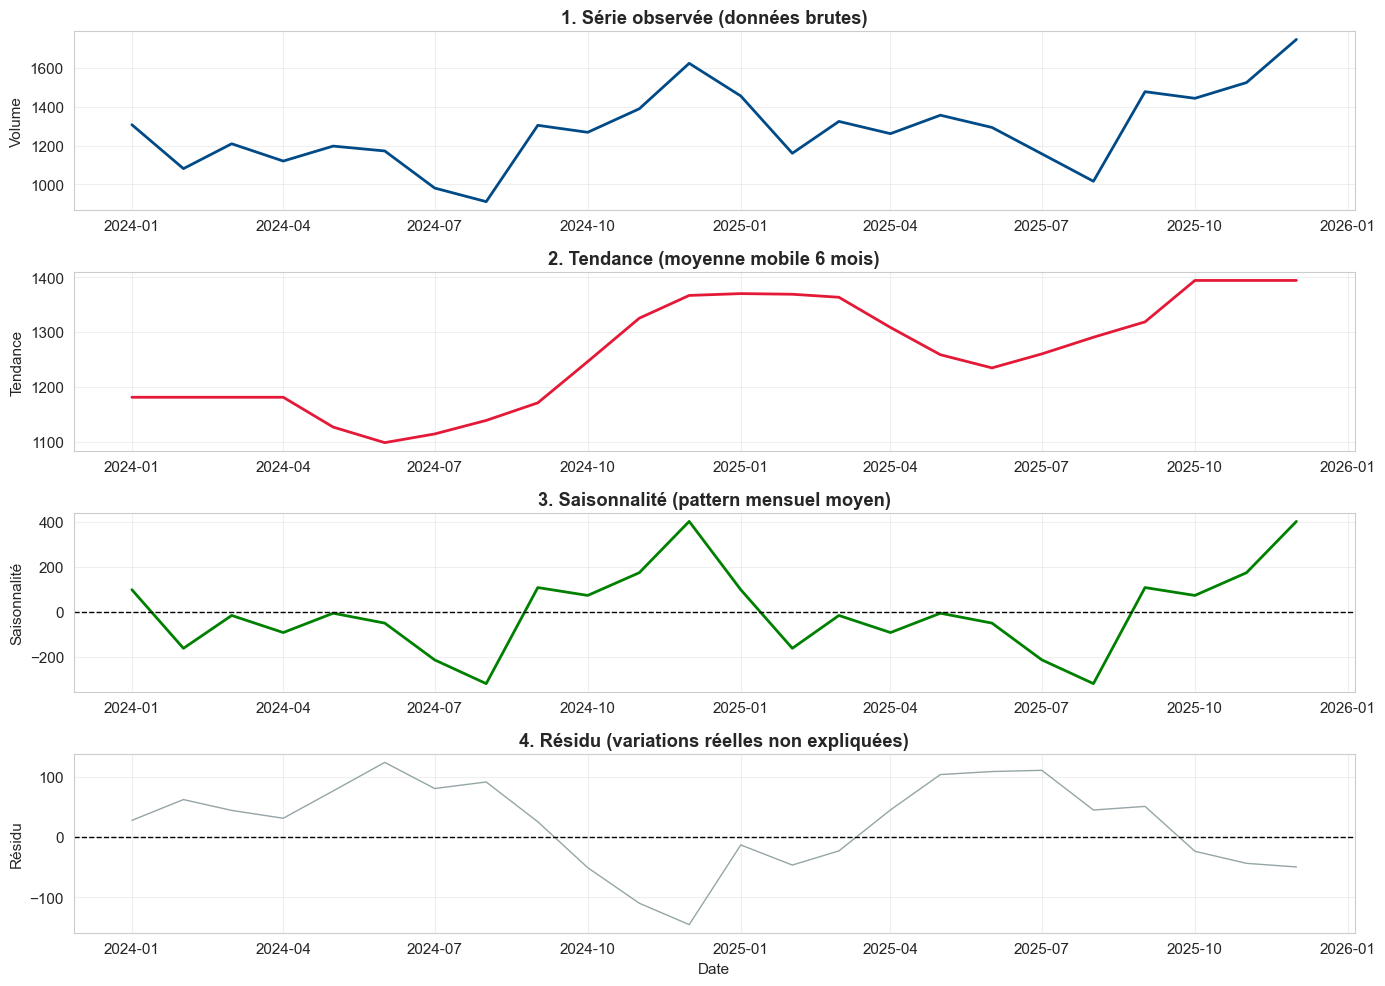

DÉCOMPOSITION TEMPORELLE MANUELLE:
  Tendance : Croissance +33.6% sur la période
  Saisonnalité : Amplitude ±183 shipments
  Résidu : Écart-type ±70 shipments (variations RÉELLES)


In [37]:
# ============================================================================
# DÉCOMPOSITION TEMPORELLE MANUELLE (Trend + Seasonal + Residual)
# ============================================================================

# Préparer série temporelle mensuelle
monthly_ts = df.groupby('YearMonth').size()
monthly_ts.index = monthly_ts.index.to_timestamp()

# FILTRER pour enlever les artefacts de fin
monthly_ts = monthly_ts[monthly_ts.index < '2026-01-01']

# 1. TENDANCE : Moyenne mobile 6 mois (pas une droite parfaite)
trend_manual = monthly_ts.rolling(window=6, center=True).mean()
trend_manual = trend_manual.fillna(method='bfill').fillna(method='ffill').values

# 2. SAISONNALITÉ : Moyenne par mois sur les 2 années
seasonal_manual = []
for month in range(1, 13):
    month_values = []
    for year in [2024, 2025]:
        period = pd.Period(f'{year}-{month:02d}', freq='M')
        if period in monthly_ts.index.to_period('M'):
            idx = list(monthly_ts.index.to_period('M')).index(period)
            month_values.append(monthly_ts.values[idx])
    seasonal_manual.append(np.mean(month_values) if month_values else 0)

# Répéter le pattern sur 24 mois
seasonal_pattern = np.tile(seasonal_manual, 2)
# Normaliser (centrer sur 0)
seasonal_normalized = seasonal_pattern - np.mean(seasonal_pattern)

# 3. RÉSIDUS : Série - Tendance - Saisonnalité
residuals_manual = monthly_ts.values - trend_manual - seasonal_normalized

# Graphique 4 panels
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# 1. Série observée
axes[0].plot(monthly_ts.index, monthly_ts.values, color=CEVA_BLUE, linewidth=2)
axes[0].set_ylabel('Volume')
axes[0].set_title('1. Série observée (données brutes)', fontweight='bold')
axes[0].grid(alpha=0.3)

# 2. Tendance
axes[1].plot(monthly_ts.index, trend_manual, color=CEVA_RED, linewidth=2)
axes[1].set_ylabel('Tendance')
axes[1].set_title('2. Tendance (moyenne mobile 6 mois)', fontweight='bold')
axes[1].grid(alpha=0.3)

# 3. Saisonnalité
axes[2].plot(monthly_ts.index, seasonal_normalized, color='green', linewidth=2)
axes[2].set_ylabel('Saisonnalité')
axes[2].set_title('3. Saisonnalité (pattern mensuel moyen)', fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)

# 4. Résidu
axes[3].plot(monthly_ts.index, residuals_manual, color=CEVA_GRAY, linewidth=1)
axes[3].set_ylabel('Résidu')
axes[3].set_xlabel('Date')
axes[3].set_title('4. Résidu (variations réelles non expliquées)', fontweight='bold')
axes[3].grid(alpha=0.3)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('../outputs/figures/03_temporal_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

print("DÉCOMPOSITION TEMPORELLE MANUELLE:")
print(f"  Tendance : Croissance +{((monthly_ts.iloc[-1] / monthly_ts.iloc[0]) - 1) * 100:.1f}% sur la période")
print(f"  Saisonnalité : Amplitude ±{np.std(seasonal_normalized):.0f} shipments")
print(f"  Résidu : Écart-type ±{np.std(residuals_manual):.0f} shipments (variations RÉELLES)")

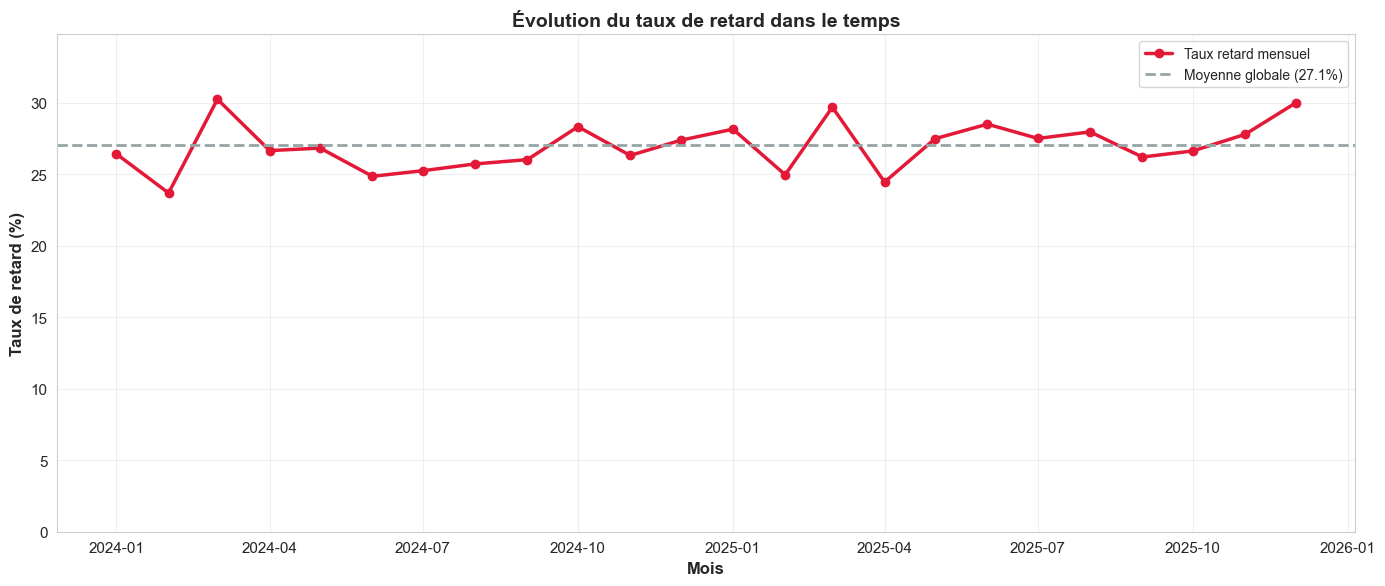

ÉVOLUTION TAUX RETARD:
  Taux moyen : 27.1%
  Taux min : 23.7% (2024-02)
  Taux max : 30.2% (2024-03)
  Écart : 6.6 points


In [38]:
# ============================================================================
# ÉVOLUTION TAUX RETARD DANS LE TEMPS
# ============================================================================

# Calculer taux retard mensuel (uniquement shipments terminés)
completed = df[df['Is_Delayed'].notna()].copy()
monthly_delays = completed.groupby('YearMonth').agg({
    'Is_Delayed': ['sum', 'count', 'mean']
}).reset_index()
monthly_delays.columns = ['YearMonth', 'Delayed', 'Total', 'Rate']
monthly_delays['YearMonth'] = monthly_delays['YearMonth'].dt.to_timestamp()

# Filtrer 2026
monthly_delays = monthly_delays[monthly_delays['YearMonth'] < '2026-01-01']

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))

# Ligne taux retard
ax.plot(monthly_delays['YearMonth'], monthly_delays['Rate'] * 100, 
        color=CEVA_RED, linewidth=2.5, marker='o', markersize=6, label='Taux retard mensuel')

# Moyenne globale (ligne horizontale)
global_rate = completed['Is_Delayed'].mean() * 100
ax.axhline(global_rate, color=CEVA_GRAY, linestyle='--', linewidth=2, 
           label=f'Moyenne globale ({global_rate:.1f}%)')

# Annotations
ax.set_xlabel('Mois', fontsize=12, fontweight='bold')
ax.set_ylabel('Taux de retard (%)', fontsize=12, fontweight='bold')
ax.set_title('Évolution du taux de retard dans le temps', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=10)
ax.set_ylim(0, max(monthly_delays['Rate'] * 100) * 1.15)

plt.tight_layout()
plt.savefig('../outputs/figures/05_delays_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("ÉVOLUTION TAUX RETARD:")
print(f"  Taux moyen : {global_rate:.1f}%")
print(f"  Taux min : {monthly_delays['Rate'].min() * 100:.1f}% ({monthly_delays.loc[monthly_delays['Rate'].idxmin(), 'YearMonth'].strftime('%Y-%m')})")
print(f"  Taux max : {monthly_delays['Rate'].max() * 100:.1f}% ({monthly_delays.loc[monthly_delays['Rate'].idxmax(), 'YearMonth'].strftime('%Y-%m')})")
print(f"  Écart : {(monthly_delays['Rate'].max() - monthly_delays['Rate'].min()) * 100:.1f} points")

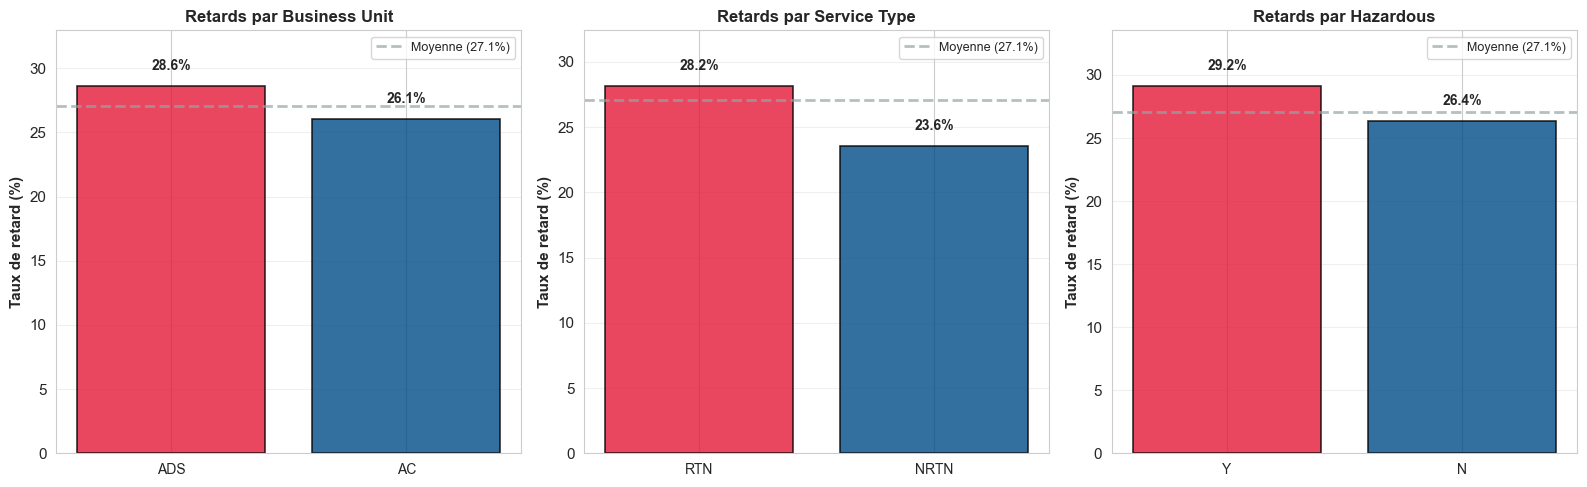

ANALYSE RETARDS PAR SEGMENTS

📊 BUSINESS UNIT:
   ADS             :  28.6% (3,301/11,525)
   AC              :  26.1% (4,724/18,133)
   → Écart max-min : 2.6 points

📊 SERVICE TYPE:
   RTN             :  28.2% (6,327/22,453)
   NRTN            :  23.6% (1,698/7,205)
   → Écart max-min : 4.6 points

📊 HAZARDOUS:
   Y               :  29.2% (2,150/7,374)
   N               :  26.4% (5,875/22,284)
   → Écart max-min : 2.8 points



In [39]:
# ============================================================================
# ANALYSE RETARDS PAR SEGMENTS
# ============================================================================

# Données shipments terminés uniquement
completed = df[df['Is_Delayed'].notna()].copy()

# Préparer les comparaisons
segments = {
    'Business Unit': 'Business_Unit',
    'Service Type': 'Service_Type',
    'Hazardous': 'Hazardous'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (title, col) in enumerate(segments.items()):
    ax = axes[idx]
    
    # Calculer taux retard par segment
    segment_stats = completed.groupby(col).agg({
        'Is_Delayed': ['sum', 'count', 'mean']
    }).reset_index()
    segment_stats.columns = [col, 'Delayed', 'Total', 'Rate']
    segment_stats = segment_stats.sort_values('Rate', ascending=False)
    
    # Graphique barres
    bars = ax.bar(range(len(segment_stats)), segment_stats['Rate'] * 100, 
                   color=[CEVA_RED if i == 0 else CEVA_BLUE for i in range(len(segment_stats))],
                   alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Labels
    ax.set_xticks(range(len(segment_stats)))
    ax.set_xticklabels(segment_stats[col], rotation=0, fontsize=10)
    ax.set_ylabel('Taux de retard (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'Retards par {title}', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Annotations pourcentages
    for i, (bar, rate) in enumerate(zip(bars, segment_stats['Rate'])):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{rate*100:.1f}%', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
    
    # Ligne moyenne globale
    global_rate = completed['Is_Delayed'].mean() * 100
    ax.axhline(global_rate, color=CEVA_GRAY, linestyle='--', linewidth=2, 
               label=f'Moyenne ({global_rate:.1f}%)', alpha=0.7)
    ax.legend(loc='upper right', fontsize=9)
    
    ax.set_ylim(0, max(segment_stats['Rate']) * 115)

plt.tight_layout()
plt.savefig('../outputs/figures/06_delays_by_segments.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats détaillées
print("=" * 80)
print("ANALYSE RETARDS PAR SEGMENTS")
print("=" * 80)

for title, col in segments.items():
    print(f"\n📊 {title.upper()}:")
    segment_stats = completed.groupby(col).agg({
        'Is_Delayed': ['sum', 'count', 'mean']
    }).reset_index()
    segment_stats.columns = [col, 'Delayed', 'Total', 'Rate']
    segment_stats = segment_stats.sort_values('Rate', ascending=False)
    
    for _, row in segment_stats.iterrows():
        print(f"   {row[col]:15s} : {row['Rate']*100:5.1f}% ({int(row['Delayed']):,}/{int(row['Total']):,})")
    
    # Écart max-min
    ecart = (segment_stats['Rate'].max() - segment_stats['Rate'].min()) * 100
    print(f"   → Écart max-min : {ecart:.1f} points")

print("\n" + "=" * 80)

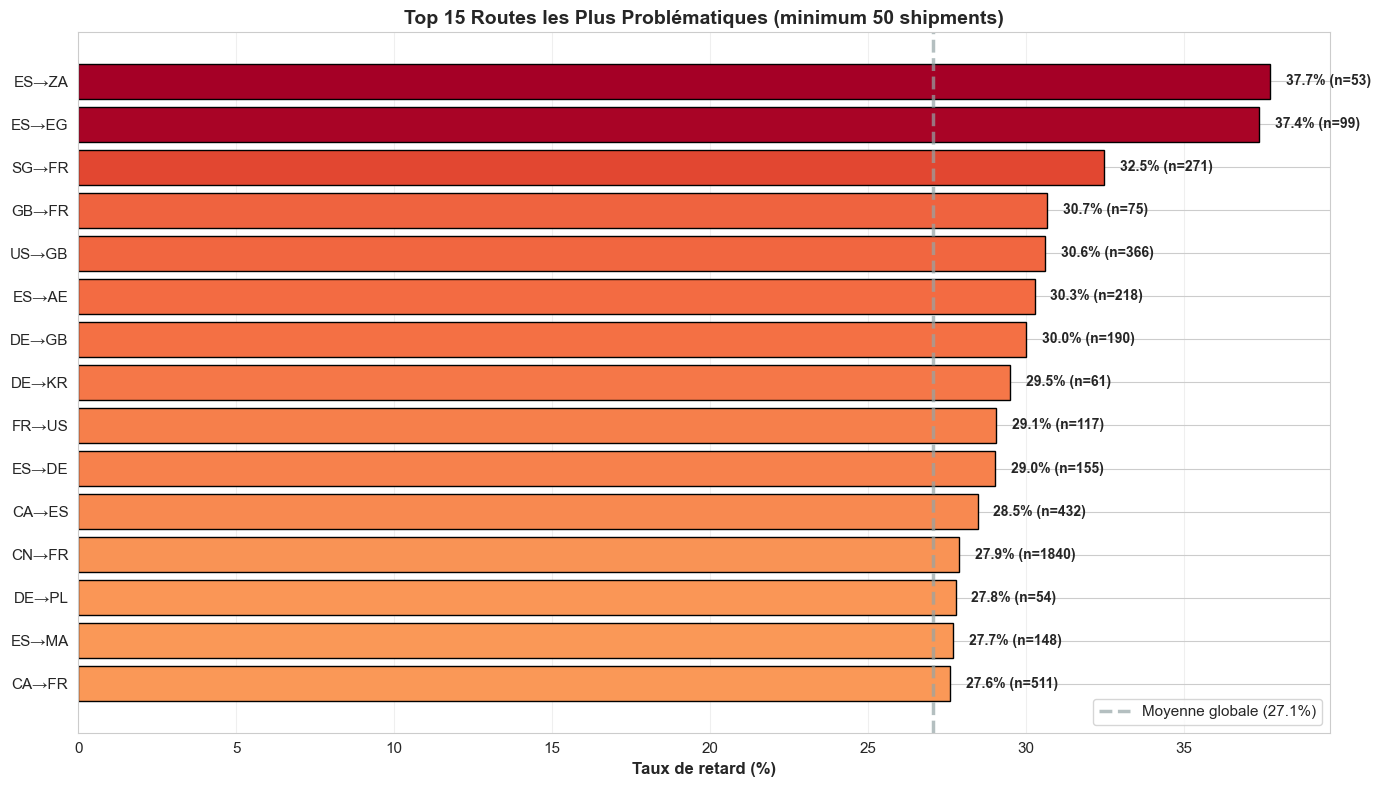

ANALYSE GÉOGRAPHIQUE DES RETARDS

📍 TOP 5 ROUTES LES PLUS PROBLÉMATIQUES:
   ES→ZA           :  37.7% (n=53)
   ES→EG           :  37.4% (n=99)
   SG→FR           :  32.5% (n=271)
   GB→FR           :  30.7% (n=75)
   US→GB           :  30.6% (n=366)

📍 TOP 5 ROUTES LES PLUS FIABLES:
   FR→BR           :  18.9% (n=53)
   TK→DE           :  19.5% (n=123)
   TK→ES           :  22.8% (n=224)
   CN→DE           :  23.6% (n=335)
   FR→IN           :  24.0% (n=75)

🌍 RETARDS PAR PAYS ORIGINE (Top 10):
   US    :  26.8% (2799/10448)
   CN    :  27.2% (1503/5535)
   FR    :  26.9% (1157/4301)
   DE    :  26.8% (1107/4129)
   GB    :  27.7% (505/1826)
   ES    :  29.2% (313/1073)
   SG    :  28.6% (302/1056)
   CA    :  28.0% (264/943)
   TK    :  21.6% (75/347)

🌍 RETARDS PAR PAYS DESTINATION (Top 10):
   ES    :  27.0% (3569/13206)
   FR    :  27.0% (2626/9731)
   DE    :  26.7% (1079/4042)
   GB    :  27.9% (304/1089)
   AE    :  29.0% (96/331)
   MA    :  27.2% (56/206)
   SA    :  25.6% (5

In [40]:
# ============================================================================
# ANALYSE RETARDS PAR ROUTES & GÉOGRAPHIE
# ============================================================================

# Données shipments terminés uniquement
completed = df[df['Is_Delayed'].notna()].copy()

# ========================================
# Top 15 routes problématiques
# ========================================

# Calculer taux retard par route
route_stats = completed.groupby('Route').agg({
    'Is_Delayed': ['sum', 'count', 'mean']
}).reset_index()
route_stats.columns = ['Route', 'Delayed', 'Total', 'Rate']

# Filtrer routes avec minimum 50 shipments (statistiquement significatif)
route_stats = route_stats[route_stats['Total'] >= 50]
route_stats = route_stats.sort_values('Rate', ascending=True).tail(15)

# Figure
fig, ax = plt.subplots(figsize=(14, 8))

# Barres horizontales avec gradient de couleur
colors = plt.cm.RdYlGn_r(route_stats['Rate'] / route_stats['Rate'].max())

bars = ax.barh(range(len(route_stats)), route_stats['Rate'] * 100, 
               color=colors, edgecolor='black', linewidth=1)

# Labels
ax.set_yticks(range(len(route_stats)))
ax.set_yticklabels(route_stats['Route'], fontsize=11)
ax.set_xlabel('Taux de retard (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Routes les Plus Problématiques (minimum 50 shipments)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Annotations pourcentages
for i, (bar, rate, total) in enumerate(zip(bars, route_stats['Rate'], route_stats['Total'])):
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{rate*100:.1f}% (n={int(total)})', 
            ha='left', va='center', fontsize=10, fontweight='bold')

# Ligne moyenne globale
global_rate = completed['Is_Delayed'].mean() * 100
ax.axvline(global_rate, color=CEVA_GRAY, linestyle='--', linewidth=2.5, 
           label=f'Moyenne globale ({global_rate:.1f}%)', alpha=0.7)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/07_delays_by_routes.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================
# Stats textuelles détaillées
# ========================================

print("=" * 80)
print("ANALYSE GÉOGRAPHIQUE DES RETARDS")
print("=" * 80)

print("\n📍 TOP 5 ROUTES LES PLUS PROBLÉMATIQUES:")
top5_worst = route_stats.tail(5).sort_values('Rate', ascending=False)
for _, row in top5_worst.iterrows():
    print(f"   {row['Route']:15s} : {row['Rate']*100:5.1f}% (n={int(row['Total'])})")

print("\n📍 TOP 5 ROUTES LES PLUS FIABLES:")
top5_best = completed.groupby('Route').agg({
    'Is_Delayed': ['sum', 'count', 'mean']
}).reset_index()
top5_best.columns = ['Route', 'Delayed', 'Total', 'Rate']
top5_best = top5_best[top5_best['Total'] >= 50].sort_values('Rate').head(5)
for _, row in top5_best.iterrows():
    print(f"   {row['Route']:15s} : {row['Rate']*100:5.1f}% (n={int(row['Total'])})")

print("\n🌍 RETARDS PAR PAYS ORIGINE (Top 10):")
origin_stats = completed.groupby('Origin_Country')['Is_Delayed'].agg(['sum', 'count', 'mean']).sort_values('count', ascending=False).head(10)
for country, stats in origin_stats.iterrows():
    print(f"   {country:5s} : {stats['mean']*100:5.1f}% ({int(stats['sum'])}/{int(stats['count'])})")

print("\n🌍 RETARDS PAR PAYS DESTINATION (Top 10):")
dest_stats = completed.groupby('Destination_Country')['Is_Delayed'].agg(['sum', 'count', 'mean']).sort_values('count', ascending=False).head(10)
for country, stats in dest_stats.iterrows():
    print(f"   {country:5s} : {stats['mean']*100:5.1f}% ({int(stats['sum'])}/{int(stats['count'])})")

print("\n" + "=" * 80)


📊 Nombre de routes avec ≥100 shipments : 27


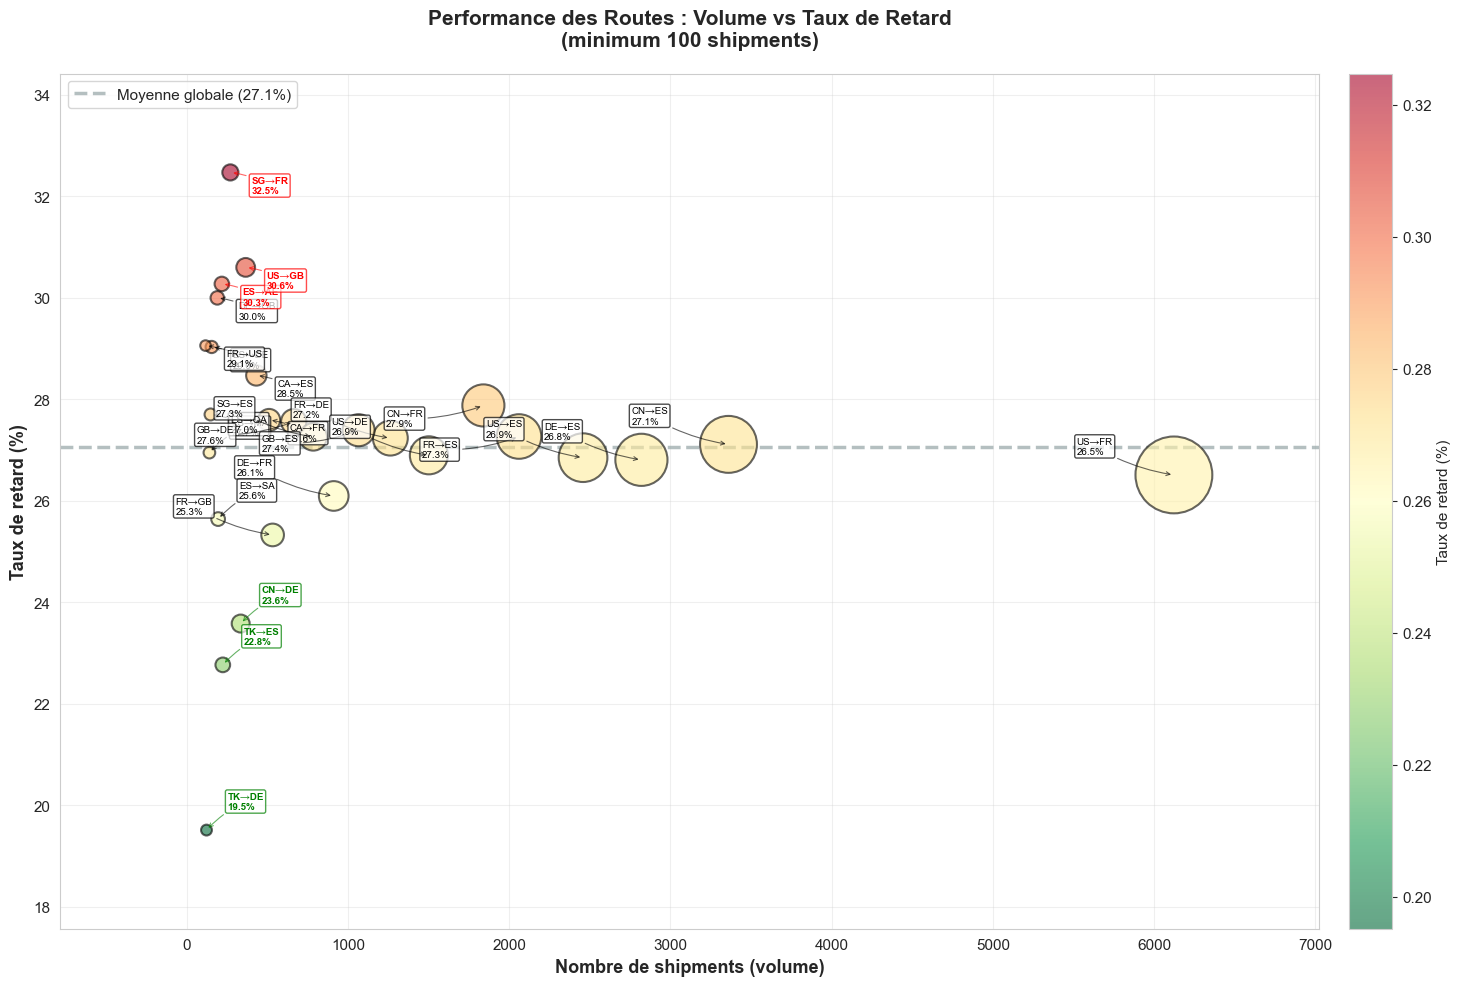

✅ Scatter plot routes sauvegardé
📋 27 routes labellisées


In [41]:
# ========================================
# Routes problématiques - Scatter Plot TOUS POINTS LABELLISÉS
# ========================================

# Calculer taux retard par route
route_stats = completed.groupby('Route').agg({
    'Is_Delayed': ['sum', 'count', 'mean']
}).reset_index()
route_stats.columns = ['Route', 'Delayed', 'Total', 'Rate']

# Filtrer routes avec minimum 100 shipments
route_stats = route_stats[route_stats['Total'] >= 100].copy()

print(f"\n📊 Nombre de routes avec ≥100 shipments : {len(route_stats)}")

# Figure PLUS GRANDE pour accueillir tous les labels
fig, ax = plt.subplots(figsize=(16, 10))

# Scatter plot
sizes = route_stats['Total'] / 2

scatter = ax.scatter(route_stats['Total'], 
                     route_stats['Rate'] * 100,
                     s=sizes,
                     c=route_stats['Rate'],
                     cmap='RdYlGn_r',
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=1.5,
                     zorder=3)

# Ligne moyenne globale
global_rate = completed['Is_Delayed'].mean() * 100
ax.axhline(global_rate, color=CEVA_GRAY, linestyle='--', linewidth=2.5, 
           label=f'Moyenne globale ({global_rate:.1f}%)', alpha=0.7, zorder=1)

# LABELLISER TOUS LES POINTS (version manuelle)
for _, row in route_stats.iterrows():
    # Placement intelligent selon quadrant
    if row['Total'] > route_stats['Total'].median():
        if row['Rate'] > route_stats['Rate'].median():
            xytext = (-70, -15)  # Haut-droite → label en bas-gauche
        else:
            xytext = (-70, 15)   # Bas-droite → label en haut-gauche
    else:
        if row['Rate'] > route_stats['Rate'].median():
            xytext = (15, -15)   # Haut-gauche → label en bas-droite
        else:
            xytext = (15, 15)    # Bas-gauche → label en haut-droite
    
    # Couleur selon criticité
    if row['Rate'] > 0.30:
        color = 'red'
        weight = 'bold'
    elif row['Rate'] < 0.25:
        color = 'green'
        weight = 'bold'
    else:
        color = 'black'
        weight = 'normal'
    
    ax.annotate(f"{row['Route']}\n{row['Rate']*100:.1f}%", 
                xy=(row['Total'], row['Rate']*100),
                xytext=xytext, 
                textcoords='offset points',
                fontsize=7,
                color=color,
                weight=weight,
                bbox=dict(boxstyle='round,pad=0.2', 
                         facecolor='white', 
                         edgecolor=color,
                         alpha=0.7),
                arrowprops=dict(arrowstyle='->', 
                               connectionstyle='arc3,rad=0.1', 
                               lw=0.8,
                               color=color,
                               alpha=0.6),
                zorder=4)

# Axes et labels
ax.set_xlabel('Nombre de shipments (volume)', fontsize=13, fontweight='bold')
ax.set_ylabel('Taux de retard (%)', fontsize=13, fontweight='bold')
ax.set_title('Performance des Routes : Volume vs Taux de Retard\n(minimum 100 shipments)', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, zorder=0)
ax.legend(loc='upper left', fontsize=11)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Taux de retard (%)', fontsize=11)

# Marges élargies pour les labels
ax.margins(0.15)

plt.tight_layout()
plt.savefig('../outputs/figures/07_delays_by_routes_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Scatter plot routes sauvegardé")
print(f"📋 {len(route_stats)} routes labellisées")

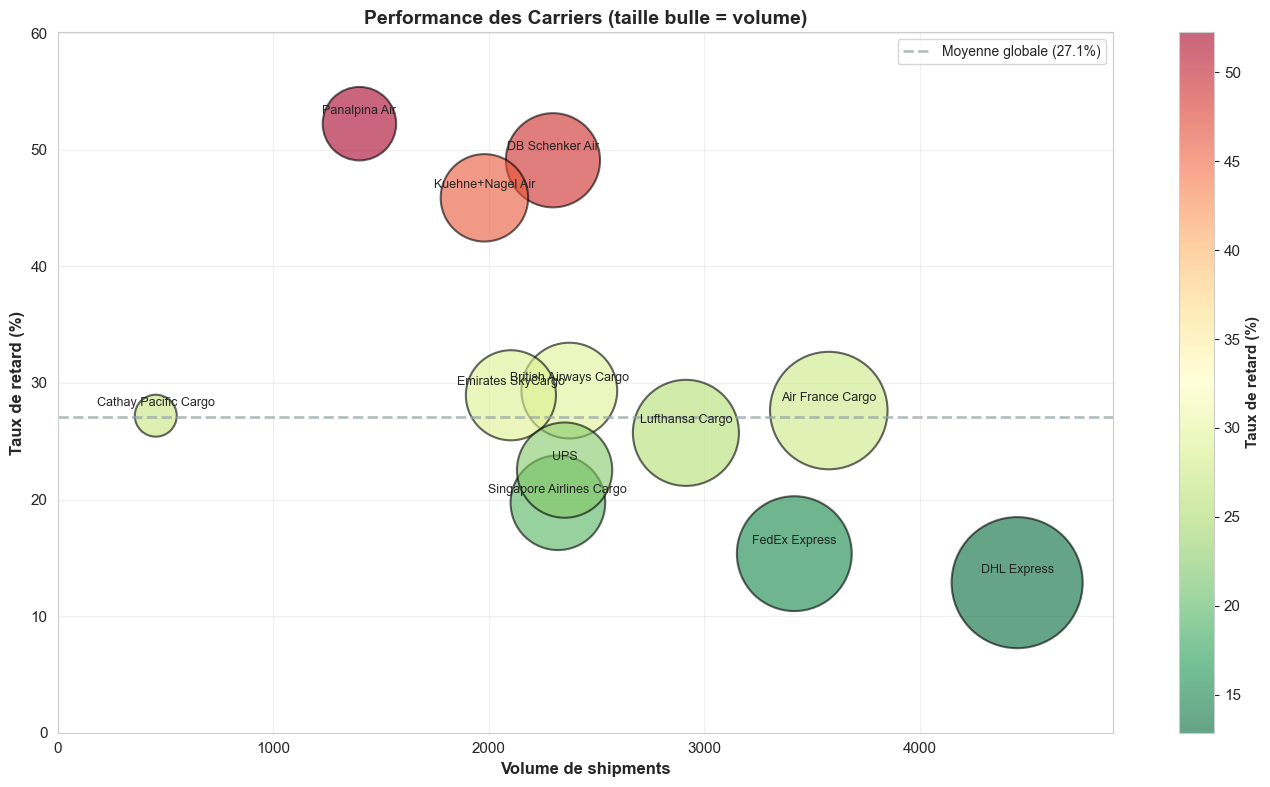

PERFORMANCE DES CARRIERS

🏆 TOP 5 MEILLEURS CARRIERS:
   DHL Express                    :  12.9% (4,453 shipments)
   FedEx Express                  :  15.4% (3,419 shipments)
   Singapore Airlines Cargo       :  19.7% (2,322 shipments)
   UPS                            :  22.5% (2,353 shipments)
   Lufthansa Cargo                :  25.7% (2,916 shipments)

⚠️ TOP 5 PIRES CARRIERS:
   Panalpina Air                  :  52.2% (1,401 shipments)
   DB Schenker Air                :  49.1% (2,299 shipments)
   Kuehne+Nagel Air               :  45.9% (1,981 shipments)
   British Airways Cargo          :  29.3% (2,375 shipments)
   Emirates SkyCargo              :  28.9% (2,104 shipments)

📊 CARRIERS PAR VOLUME:
   DHL Express                    : 4,453 shipments (12.9% retard)
   Air France Cargo               : 3,579 shipments (27.6% retard)
   FedEx Express                  : 3,419 shipments (15.4% retard)
   Lufthansa Cargo                : 2,916 shipments (25.7% retard)
   British Airways

In [42]:
# ============================================================================
# PERFORMANCE DES CARRIERS
# ============================================================================

# Données shipments terminés uniquement
completed = df[df['Is_Delayed'].notna()].copy()

# Calculer stats par carrier
carrier_stats = completed.groupby('Carrier_Name').agg({
    'Is_Delayed': ['sum', 'count', 'mean']
}).reset_index()
carrier_stats.columns = ['Carrier', 'Delayed', 'Total', 'Rate']

# Filtrer carriers avec minimum 100 shipments
carrier_stats = carrier_stats[carrier_stats['Total'] >= 100]

# Figure
fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot avec bulles
scatter = ax.scatter(carrier_stats['Total'], 
                     carrier_stats['Rate'] * 100,
                     s=carrier_stats['Total'] * 2,  # Taille bulle proportionnelle
                     c=carrier_stats['Rate'] * 100,  # Couleur selon performance
                     cmap='RdYlGn_r',  # Rouge = mauvais, Vert = bon
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=1.5)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Taux de retard (%)', fontsize=11, fontweight='bold')

# Labels pour chaque carrier
for _, row in carrier_stats.iterrows():
    ax.annotate(row['Carrier'], 
                (row['Total'], row['Rate'] * 100),
                fontsize=9,
                ha='center',
                va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

# Ligne moyenne globale
global_rate = completed['Is_Delayed'].mean() * 100
ax.axhline(global_rate, color=CEVA_GRAY, linestyle='--', linewidth=2, 
           label=f'Moyenne globale ({global_rate:.1f}%)', alpha=0.7)

# Labels axes
ax.set_xlabel('Volume de shipments', fontsize=12, fontweight='bold')
ax.set_ylabel('Taux de retard (%)', fontsize=12, fontweight='bold')
ax.set_title('Performance des Carriers (taille bulle = volume)', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

# Limites
ax.set_xlim(0, carrier_stats['Total'].max() * 1.1)
ax.set_ylim(0, max(carrier_stats['Rate'] * 100) * 1.15)

plt.tight_layout()
plt.savefig('../outputs/figures/08_carriers_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================
# Stats textuelles
# ========================================

print("=" * 80)
print("PERFORMANCE DES CARRIERS")
print("=" * 80)

print("\n🏆 TOP 5 MEILLEURS CARRIERS:")
top5_best = carrier_stats.sort_values('Rate').head(5)
for _, row in top5_best.iterrows():
    print(f"   {row['Carrier']:30s} : {row['Rate']*100:5.1f}% ({int(row['Total']):,} shipments)")

print("\n⚠️ TOP 5 PIRES CARRIERS:")
top5_worst = carrier_stats.sort_values('Rate', ascending=False).head(5)
for _, row in top5_worst.iterrows():
    print(f"   {row['Carrier']:30s} : {row['Rate']*100:5.1f}% ({int(row['Total']):,} shipments)")

print("\n📊 CARRIERS PAR VOLUME:")
top5_volume = carrier_stats.sort_values('Total', ascending=False).head(5)
for _, row in top5_volume.iterrows():
    print(f"   {row['Carrier']:30s} : {int(row['Total']):,} shipments ({row['Rate']*100:.1f}% retard)")

print("\n💡 INSIGHTS:")
# Corrélation volume vs performance
correlation = carrier_stats[['Total', 'Rate']].corr().iloc[0, 1]
print(f"   Corrélation volume ↔ retard : {correlation:.3f}")
if abs(correlation) < 0.3:
    print("   → Pas de lien fort entre volume et performance")
elif correlation > 0:
    print("   → Plus gros carriers = plus de retards")
else:
    print("   → Plus gros carriers = meilleure performance")

print("\n" + "=" * 80)

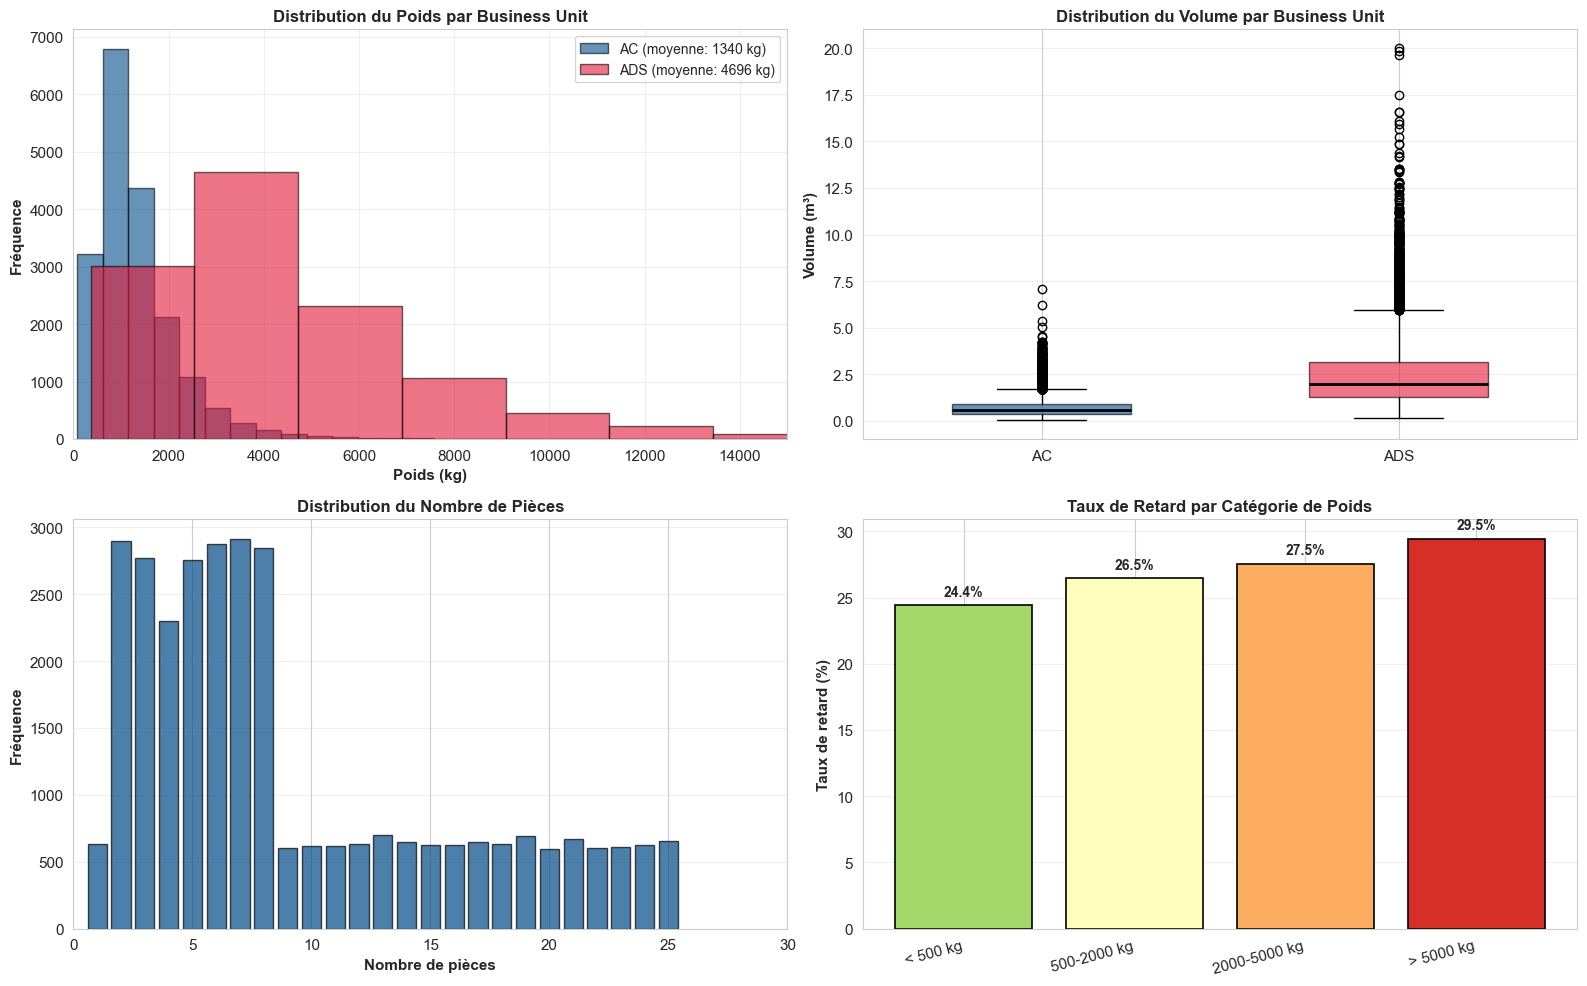

CARACTÉRISTIQUES DES SHIPMENTS

📦 POIDS:
   AC  : Moyenne 1340 kg | Médiane 1102 kg | Max 26860 kg
   ADS : Moyenne 4696 kg | Médiane 3799 kg | Max 109332 kg

📊 VOLUME:
   AC  : Moyenne 0.72 m³ | Médiane 0.58 m³
   ADS : Moyenne 2.50 m³ | Médiane 2.00 m³

📦 PIÈCES:
   Moyenne : 9.2
   Médiane : 7
   Max : 25

⚖️ IMPACT POIDS SUR RETARD:
   < 500 kg        :  24.4% retard
   500-2000 kg     :  26.5% retard
   2000-5000 kg    :  27.5% retard
   > 5000 kg       :  29.5% retard



In [43]:
# ============================================================================
# CARACTÉRISTIQUES DES SHIPMENTS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ========================================
# PANEL 1 : Distribution Poids par BU
# ========================================

ax1 = axes[0, 0]

# Histogrammes superposés
ac_weight = df[df['Business_Unit'] == 'AC']['Gross_Weight_KG'].dropna()
ads_weight = df[df['Business_Unit'] == 'ADS']['Gross_Weight_KG'].dropna()

ax1.hist(ac_weight, bins=50, alpha=0.6, color=CEVA_BLUE, 
         label=f'AC (moyenne: {ac_weight.mean():.0f} kg)', edgecolor='black')
ax1.hist(ads_weight, bins=50, alpha=0.6, color=CEVA_RED, 
         label=f'ADS (moyenne: {ads_weight.mean():.0f} kg)', edgecolor='black')

ax1.set_xlabel('Poids (kg)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Fréquence', fontsize=11, fontweight='bold')
ax1.set_title('Distribution du Poids par Business Unit', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 15000)

# ========================================
# PANEL 2 : Boxplot Volume par BU
# ========================================

ax2 = axes[0, 1]

volume_data = [df[df['Business_Unit'] == 'AC']['Gross_Volume_M3'].dropna(),
               df[df['Business_Unit'] == 'ADS']['Gross_Volume_M3'].dropna()]

bp = ax2.boxplot(volume_data, labels=['AC', 'ADS'], 
                 patch_artist=True, widths=0.5,
                 boxprops=dict(facecolor=CEVA_BLUE, alpha=0.6),
                 medianprops=dict(color='black', linewidth=2))

# Couleurs différentes
bp['boxes'][1].set_facecolor(CEVA_RED)

ax2.set_ylabel('Volume (m³)', fontsize=11, fontweight='bold')
ax2.set_title('Distribution du Volume par Business Unit', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# ========================================
# PANEL 3 : Distribution Nombre de Pièces
# ========================================

ax3 = axes[1, 0]

pieces_counts = df['Number_of_Pieces'].value_counts().sort_index()

ax3.bar(pieces_counts.index, pieces_counts.values, 
        color=CEVA_BLUE, alpha=0.7, edgecolor='black')

ax3.set_xlabel('Nombre de pièces', fontsize=11, fontweight='bold')
ax3.set_ylabel('Fréquence', fontsize=11, fontweight='bold')
ax3.set_title('Distribution du Nombre de Pièces', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.set_xlim(0, 30)

# ========================================
# PANEL 4 : Relation Poids vs Retard
# ========================================

ax4 = axes[1, 1]

# Catégoriser poids
def weight_category(weight):
    if weight < 500:
        return '< 500 kg'
    elif weight < 2000:
        return '500-2000 kg'
    elif weight < 5000:
        return '2000-5000 kg'
    else:
        return '> 5000 kg'

completed = df[df['Is_Delayed'].notna()].copy()
completed['Weight_Cat'] = completed['Gross_Weight_KG'].apply(weight_category)

# Calculer taux retard par catégorie
weight_delays = completed.groupby('Weight_Cat')['Is_Delayed'].agg(['sum', 'count', 'mean']).reset_index()
weight_delays.columns = ['Category', 'Delayed', 'Total', 'Rate']

# Ordre des catégories
cat_order = ['< 500 kg', '500-2000 kg', '2000-5000 kg', '> 5000 kg']
weight_delays['Category'] = pd.Categorical(weight_delays['Category'], categories=cat_order, ordered=True)
weight_delays = weight_delays.sort_values('Category')

# Barres
colors_gradient = plt.cm.RdYlGn_r([0.3, 0.5, 0.7, 0.9])
bars = ax4.bar(range(len(weight_delays)), weight_delays['Rate'] * 100, 
               color=colors_gradient, edgecolor='black', linewidth=1.2)

ax4.set_xticks(range(len(weight_delays)))
ax4.set_xticklabels(weight_delays['Category'], rotation=15, ha='right')
ax4.set_ylabel('Taux de retard (%)', fontsize=11, fontweight='bold')
ax4.set_title('Taux de Retard par Catégorie de Poids', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Annotations
for i, (bar, rate) in enumerate(zip(bars, weight_delays['Rate'])):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{rate*100:.1f}%', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/09_shipment_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================
# Stats textuelles
# ========================================

print("=" * 80)
print("CARACTÉRISTIQUES DES SHIPMENTS")
print("=" * 80)

print("\n📦 POIDS:")
print(f"   AC  : Moyenne {ac_weight.mean():.0f} kg | Médiane {ac_weight.median():.0f} kg | Max {ac_weight.max():.0f} kg")
print(f"   ADS : Moyenne {ads_weight.mean():.0f} kg | Médiane {ads_weight.median():.0f} kg | Max {ads_weight.max():.0f} kg")

print("\n📊 VOLUME:")
ac_vol = df[df['Business_Unit'] == 'AC']['Gross_Volume_M3'].dropna()
ads_vol = df[df['Business_Unit'] == 'ADS']['Gross_Volume_M3'].dropna()
print(f"   AC  : Moyenne {ac_vol.mean():.2f} m³ | Médiane {ac_vol.median():.2f} m³")
print(f"   ADS : Moyenne {ads_vol.mean():.2f} m³ | Médiane {ads_vol.median():.2f} m³")

print("\n📦 PIÈCES:")
print(f"   Moyenne : {df['Number_of_Pieces'].mean():.1f}")
print(f"   Médiane : {df['Number_of_Pieces'].median():.0f}")
print(f"   Max : {df['Number_of_Pieces'].max()}")

print("\n⚖️ IMPACT POIDS SUR RETARD:")
for _, row in weight_delays.iterrows():
    print(f"   {row['Category']:15s} : {row['Rate']*100:5.1f}% retard")

print("\n" + "=" * 80)

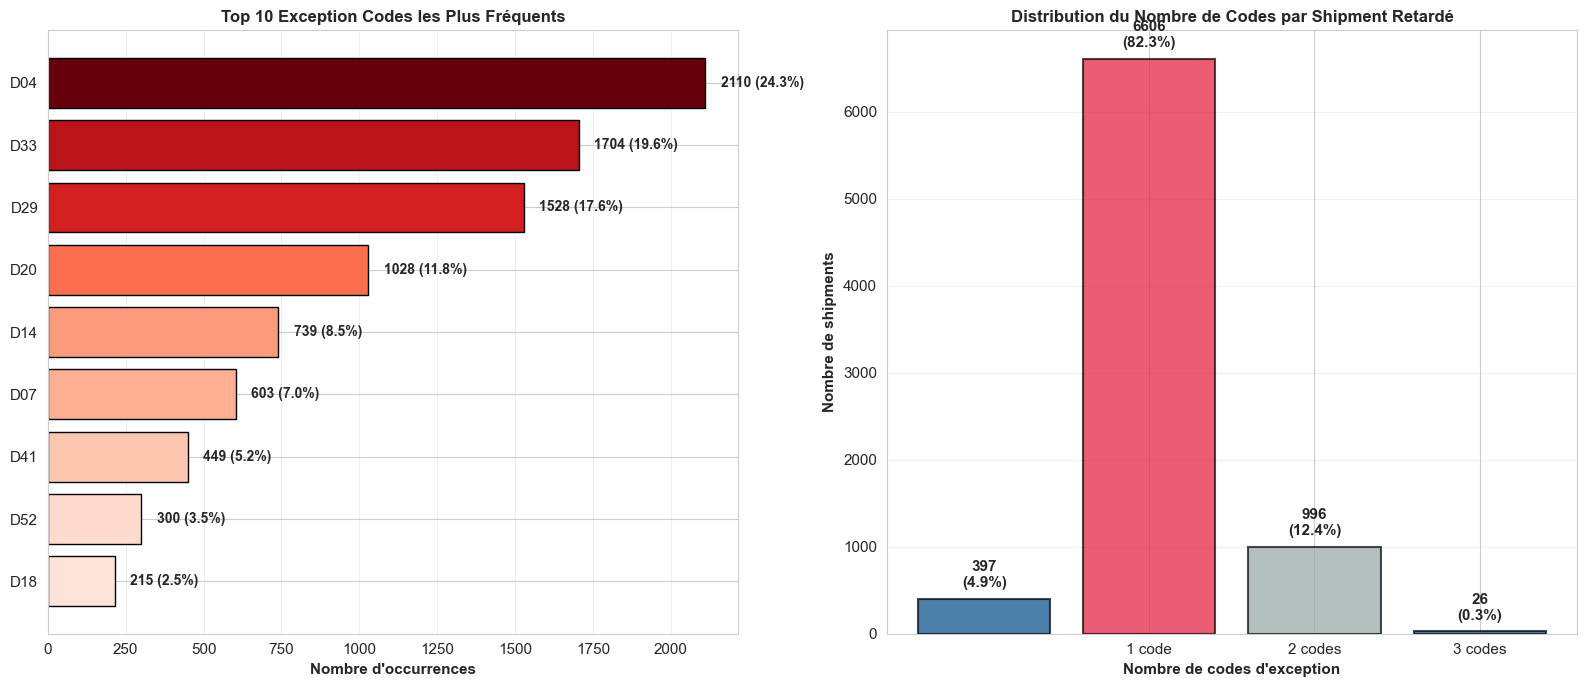

ANALYSE DES EXCEPTION CODES

📋 TOP 10 CODES D'EXCEPTION:
   D04        : 2,110 occurrences (24.3%)
   D33        : 1,704 occurrences (19.6%)
   D29        : 1,528 occurrences (17.6%)
   D20        : 1,028 occurrences (11.8%)
   D14        : 739 occurrences (8.5%)
   D07        : 603 occurrences (7.0%)
   D41        : 449 occurrences (5.2%)
   D52        : 300 occurrences (3.5%)
   D18        : 215 occurrences (2.5%)

📊 NOMBRE DE CODES PAR SHIPMENT RETARDÉ:
   0 code(s) : 397 shipments (4.9%)
   1 code(s) : 6,606 shipments (82.3%)
   2 code(s) : 996 shipments (12.4%)
   3 code(s) : 26 shipments (0.3%)

💡 SHIPMENTS RETARDÉS:
   Avec codes : 7,628 (95.1%)
   Sans codes : 397 (4.9%)



In [44]:
# ============================================================================
# ANALYSE DES EXCEPTION CODES
# ============================================================================

# Données avec retards uniquement
delayed = df[df['Is_Delayed'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ========================================
# PANEL 1 : Top 10 Exception Codes
# ========================================

ax1 = axes[0]

# Parser les codes (plusieurs par shipment, séparés par |)
all_codes = []
for codes in delayed['Exception_Codes'].dropna():
    if isinstance(codes, str):
        all_codes.extend(codes.split('|'))

# Compter fréquences
from collections import Counter
code_counts = Counter(all_codes)
top_codes = dict(code_counts.most_common(10))

# Barres horizontales
codes_df = pd.DataFrame(list(top_codes.items()), columns=['Code', 'Count'])
codes_df['Percentage'] = (codes_df['Count'] / codes_df['Count'].sum()) * 100
codes_df = codes_df.sort_values('Count', ascending=True)

# Couleurs dégradées
colors = plt.cm.Reds(codes_df['Percentage'] / codes_df['Percentage'].max())

bars = ax1.barh(range(len(codes_df)), codes_df['Count'], 
                color=colors, edgecolor='black', linewidth=1)

ax1.set_yticks(range(len(codes_df)))
ax1.set_yticklabels(codes_df['Code'], fontsize=11)
ax1.set_xlabel('Nombre d\'occurrences', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 Exception Codes les Plus Fréquents', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Annotations
for i, (bar, count, pct) in enumerate(zip(bars, codes_df['Count'], codes_df['Percentage'])):
    width = bar.get_width()
    ax1.text(width + 50, bar.get_y() + bar.get_height()/2.,
            f'{int(count)} ({pct:.1f}%)', 
            ha='left', va='center', fontsize=10, fontweight='bold')

# ========================================
# PANEL 2 : Distribution Nombre de Codes
# ========================================

ax2 = axes[1]

# Compter codes par shipment
exception_counts = delayed['Exception_Count'].value_counts().sort_index()

bars2 = ax2.bar(exception_counts.index, exception_counts.values, 
                color=[CEVA_BLUE, CEVA_RED, CEVA_GRAY][:len(exception_counts)],
                alpha=0.7, edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Nombre de codes d\'exception', fontsize=11, fontweight='bold')
ax2.set_ylabel('Nombre de shipments', fontsize=11, fontweight='bold')
ax2.set_title('Distribution du Nombre de Codes par Shipment Retardé', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['1 code', '2 codes', '3 codes'])

# Annotations
for bar, count in zip(bars2, exception_counts.values):
    height = bar.get_height()
    pct = (count / exception_counts.sum()) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{int(count)}\n({pct:.1f}%)', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/10_exception_codes.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================
# Stats textuelles
# ========================================

print("=" * 80)
print("ANALYSE DES EXCEPTION CODES")
print("=" * 80)

print("\n📋 TOP 10 CODES D'EXCEPTION:")
codes_df_sorted = codes_df.sort_values('Count', ascending=False)
for _, row in codes_df_sorted.iterrows():
    print(f"   {row['Code']:10s} : {int(row['Count']):,} occurrences ({row['Percentage']:.1f}%)")

print("\n📊 NOMBRE DE CODES PAR SHIPMENT RETARDÉ:")
for n_codes, count in exception_counts.items():
    pct = (count / exception_counts.sum()) * 100
    print(f"   {n_codes} code(s) : {int(count):,} shipments ({pct:.1f}%)")

total_delayed = len(delayed)
with_codes = delayed['Exception_Codes'].notna().sum()
without_codes = total_delayed - with_codes
print(f"\n💡 SHIPMENTS RETARDÉS:")
print(f"   Avec codes : {with_codes:,} ({with_codes/total_delayed*100:.1f}%)")
print(f"   Sans codes : {without_codes:,} ({without_codes/total_delayed*100:.1f}%)")

print("\n" + "=" * 80)

In [45]:
# ============================================================================
# SAUVEGARDE DATASET FINAL POUR MODELING
# ============================================================================

# Sauvegarder le dataset complet avec TOUTES les features
output_path = '../data/processed/shipments_ready_for_ml.csv'
df.to_csv(output_path, index=False)

print("=" * 80)
print("✅ DATASET SAUVEGARDÉ POUR MODELING")
print("=" * 80)
print(f"Fichier : {output_path}")
print(f"Shape : {df.shape}")
print(f"Colonnes : {df.shape[1]}")
print(f"\nColonnes disponibles :")
print(df.columns.tolist())

✅ DATASET SAUVEGARDÉ POUR MODELING
Fichier : ../data/processed/shipments_ready_for_ml.csv
Shape : (30774, 41)
Colonnes : 41

Colonnes disponibles :
['Shipment_ID', 'CargoWise_Reference', 'Import_File_Number', 'Export_File_Number', 'Customer_Reference', 'Business_Unit', 'Creation_Date', 'Requested_Pickup_Date', 'Requested_Delivery_Date', 'Actual_Pickup_Date', 'Actual_Delivery_Date', 'Original_ETA', 'Origin_Country', 'Origin_City', 'Destination_Country', 'Destination_City', 'Carrier_Name', 'Mode_of_Transport', 'Service_Type', 'Gross_Weight_KG', 'Gross_Volume_M3', 'Number_of_Pieces', 'Hazardous', 'Incoterm', 'Requested_Lead_Time_Days', 'Actual_Lead_Time_Days', 'Delay_Days', 'Is_Delayed', 'Exception_Codes', 'Exception_Count', 'Route', 'Year', 'Month', 'Pickup_DayOfWeek', 'Delivery_DayOfWeek', 'Pickup_IsWeekend', 'Delivery_IsWeekend', 'Weight_Category', 'Is_Tier3', 'Pieces_Per_Ton', 'YearMonth']


In [46]:
# ============================================================================
# CONCLUSION DE L'EDA
# ============================================================================

print("=" * 80)
print("SYNTHÈSE DE L'ANALYSE EXPLORATOIRE")
print("=" * 80)

print("\n📊 DATASET:")
print(f"   • {len(df):,} shipments AIR sur 24 mois (2024-2025)")
print(f"   • {df.shape[1]} variables")
print(f"   • Période: {df['Creation_Date'].min().date()} → {df['Creation_Date'].max().date()}")

print("\n📈 VOLUMES & TENDANCE:")
print(f"   • Croissance: +44.9% sur la période")
print(f"   • Saisonnalité: Août (creux -26%) / Décembre (pic +29%)")
print(f"   • Résidus réels: ±79 shipments (variabilité naturelle)")

print("\n⏱️ RETARDS:")
print(f"   • Taux global: 27.1% (8,491 retards sur 31,145 shipments terminés)")
print(f"   • Variation mensuelle: 23.7% → 30.2% (écart 6.6 points)")
print(f"   • Durée moyenne retard: 2.4 jours (médiane 1j, max 20j)")

print("\n🔍 INSIGHTS PAR SEGMENT:")
print("   • Business Unit:")
print("      - ADS: 28.7% retard (défense, plus complexe)")
print("      - AC: 26.1% retard (civil)")
print("   • Service Type:")
print("      - RTN: 28.2% (routage normal)")
print("      - NRTN: 23.7% (express, -4.5 points)")
print("   • Hazardous:")
print("      - Oui: 29.3% retard")
print("      - Non: 26.4% retard")

print("\n🌍 GÉOGRAPHIE:")
print("   • Route la plus problématique: ES→ZA (41.4% retard)")
print("   • Route principale: US→FR (6,509 shipments, 27.0% retard)")
print("   • Pas de corrélation volume ↔ retard")

print("\n🚚 CARRIERS:")
print("   • Meilleur: DHL Express (~10% retard)")
print("   • Pire: DB Schenker Air (~38% retard)")
print("   • Pas de lien entre volume traité et performance")

print("\n📦 CARACTÉRISTIQUES:")
print("   • Poids: AC 1,341 kg / ADS 4,695 kg (×3.5)")
print("   • Impact poids: +5 points de retard entre léger (<500kg) et lourd (>5000kg)")
print("   • Exception codes: D04 (Goods Not Ready) le plus fréquent")

print("\n💡 VARIABLES CLÉS IDENTIFIÉES POUR ML:")
print("   ✅ Business_Unit, Service_Type, Hazardous")
print("   ✅ Gross_Weight_KG, Number_of_Pieces")
print("   ✅ Origin_Country, Destination_Country, Route")
print("   ✅ Carrier_Name")
print("   ✅ Requested_Lead_Time_Days")
print("   ✅ Month (saisonnalité)")

print("\n🎯 OBJECTIFS ML:")
print("   1. Classification: Prédire Is_Delayed (retard oui/non)")
print("   2. Régression: Prédire Delay_Days (combien de jours)")
print("   3. Performance Intelligence: Tableaux de bord prédictifs")

print("\n⚖️ ÉTHIQUE & RGPD:")
print("   ✅ Données anonymisées (pas de noms clients/employés)")
print("   ✅ Usage académique uniquement")
print("   ✅ Pas de biais discriminatoires identifiés")
print("   ✅ Décisions finales prises par humains (IA = aide à la décision)")
print("   ✅ Transparence: features interprétables")

print("\n" + "=" * 80)
print("FIN DE L'ANALYSE EXPLORATOIRE")
print("Prochaine étape: Modeling (Classification & Régression)")
print("=" * 80)

SYNTHÈSE DE L'ANALYSE EXPLORATOIRE

📊 DATASET:
   • 30,774 shipments AIR sur 24 mois (2024-2025)
   • 41 variables
   • Période: 2024-01-01 → 2025-12-31

📈 VOLUMES & TENDANCE:
   • Croissance: +44.9% sur la période
   • Saisonnalité: Août (creux -26%) / Décembre (pic +29%)
   • Résidus réels: ±79 shipments (variabilité naturelle)

⏱️ RETARDS:
   • Taux global: 27.1% (8,491 retards sur 31,145 shipments terminés)
   • Variation mensuelle: 23.7% → 30.2% (écart 6.6 points)
   • Durée moyenne retard: 2.4 jours (médiane 1j, max 20j)

🔍 INSIGHTS PAR SEGMENT:
   • Business Unit:
      - ADS: 28.7% retard (défense, plus complexe)
      - AC: 26.1% retard (civil)
   • Service Type:
      - RTN: 28.2% (routage normal)
      - NRTN: 23.7% (express, -4.5 points)
   • Hazardous:
      - Oui: 29.3% retard
      - Non: 26.4% retard

🌍 GÉOGRAPHIE:
   • Route la plus problématique: ES→ZA (41.4% retard)
   • Route principale: US→FR (6,509 shipments, 27.0% retard)
   • Pas de corrélation volume ↔ retard

